In [1]:
#parameters

### USER EDIT start
# esm_file='/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json'
# esm_file='/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/experiment_datastore.json'
esm_file = '/scratch/ps29/nd0349/access-om3/archive/IC4M8-MCW-100km_jra_iaf_2010/experiment_datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-om3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /scratch/ps29/nd0349/access-om3/archive/IC4M8-MCW-100km_jra_iaf_2010/experiment_datastore.json
Plot folder path:  /g/data/ps29/nd0349/access-om3-paper-figs/


In [2]:
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import cftime
import os
import matplotlib.pyplot as plt
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
from textwrap import wrap
xr.set_options(keep_attrs=True);  # cf_xarray works best when xarray keeps attributes by default

In [3]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39089 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/39089/status,
Dashboard: /proxy/39089/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37903,Workers: 0
Dashboard: /proxy/39089/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39213,Total threads: 1
Dashboard: /proxy/39425/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:45297,


### Define plot function

In [4]:
blue_marble = plt.imread('/g/data/ik11/grids/BlueMarble.tiff')
blue_marble_extent = (-180, 180, -90, 90)

In [5]:
# def plot(dat, title=None, **kwargs):
#     if title is None:
#         title = dat.attrs['long_name']
#     fig = plt.figure(figsize=(12, 6))
#     ax = plt.axes(projection=ccrs.Robinson(central_longitude=-100))
#     dat.plot.contourf(
#         ax=ax,
#         transform=ccrs.PlateCarree(),
#         cbar_kwargs={"label": "\n".join(wrap(f"{dat.attrs['long_name']} [{dat.attrs['units']}]", 45)),
#                      "fraction": 0.03, "aspect": 15, "shrink": 0.7},
#         **kwargs
#     )
    
#     # Add blue marble land:
#     ax.imshow(
#         blue_marble, extent=blue_marble_extent, transform=ccrs.PlateCarree(), origin="upper"
#     )
    
#     plt.title(title);

### Load and plot data from ACCESS-OM3

In [6]:
exptname = os.path.basename(os.path.dirname(esm_file))

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
    ]
)

In [7]:
exptname

'IC4M8-MCW-100km_jra_iaf_2010'

In [8]:
geolon = datastore.search(variable="geolon", file_id='access_om3_mom6_static').to_dask().geolon
geolat = datastore.search(variable="geolat", file_id='access_om3_mom6_static').to_dask().geolat

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [9]:
variable = "tos"
sst = datastore.search(variable=variable, frequency="1day").to_dask(
    xarray_open_kwargs = dict(
        chunks={"time": -1},
        decode_timedelta=True
    ),
    xarray_combine_by_coords_kwargs=dict(
        compat="override",
        data_vars="minimal",
        coords="minimal"
    )
)[variable].cf.assign_coords({ "longitude": geolon, "latitude": geolat })

In [10]:
sst

<xarray.DataArray 'tos' (time: 5113, yh: 300, xh: 360)> Size: 2GB
dask.array<concatenate, shape=(5113, 300, 360), dtype=float32, chunksize=(31, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 41kB 2010-01-01T12:00:00 ... 2023-12-31T12...
    yh       (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    xh       (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    units:          degC
    long_name:      Sea Surface Temperature
    cell_methods:   area:mean yh:mean xh:mean time: mean
    cell_measures:  area: areacello
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_surface_temperature

In [11]:
geolon

<xarray.DataArray 'geolon' (yh: 300, xh: 360)> Size: 864kB
dask.array<open_dataset-geolon, shape=(300, 360), dtype=float64, chunksize=(300, 360), chunktype=numpy.ndarray>
Coordinates:
  * yh       (yh) float64 2kB -77.88 -77.63 -77.38 -77.13 ... 88.87 89.32 89.77
  * xh       (xh) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
Attributes:
    units:         degrees_east
    long_name:     Longitude of tracer (T) points
    cell_methods:  time: point

In [12]:
variable = "HS"
swh = datastore.search(variable=variable, frequency="fx").to_dask(
    xarray_open_kwargs = dict(
        chunks={"time": -1},
        decode_timedelta=True
    ),
    xarray_combine_by_coords_kwargs=dict(
        compat="override",
        data_vars="minimal",
        coords="minimal"
    )
).rename({'ny': 'yh', 'nx': 'xh'})[variable].cf.assign_coords({ "longitude": geolon, "latitude": geolat })

In [13]:
swh

<xarray.DataArray 'HS' (time: 5113, yh: 300, xh: 360)> Size: 2GB
dask.array<concatenate, shape=(5113, 300, 360), dtype=float32, chunksize=(1, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 41kB 2010-01-02 2010-01-03 ... 2037-11-30
  * yh         (yh) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xh         (xh) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
    latitude   (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    units:      m
    long_name:  Significant wave height

In [14]:
variable = "aice"
aice = datastore.search(variable=variable, frequency="1day", file_id='access_om3_cice_1day_mean_XXXX_XX').to_dask(
    xarray_open_kwargs = dict(
        chunks={"time": -1},
        decode_timedelta=True
    ),
    xarray_combine_by_coords_kwargs=dict(
        compat="override",
        data_vars="minimal",
        coords="minimal"
    )
).rename({'nj': 'yh', 'ni': 'xh'})[variable].cf.assign_coords({ "longitude": geolon, "latitude": geolat })

In [15]:
aice

<xarray.DataArray 'aice' (time: 4992, yh: 300, xh: 360)> Size: 4GB
dask.array<concatenate, shape=(4992, 300, 360), dtype=float64, chunksize=(31, 150, 180), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 40kB 2010-01-01T12:00:00 ... 2023-12-31T...
  * yh         (yh) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xh         (xh) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
    latitude   (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    units:          1
    long_name:      ice area  (aggregate)
    cell_measures:  area: tarea
    cell_methods:   time: mean
    time_rep:       averaged

In [16]:
variable = "fsdrad"
fsdrad = datastore.search(variable=variable, frequency="1day", file_id='access_om3_cice_1day_mean_XXXX_XX').to_dask(
    xarray_open_kwargs = dict(
        chunks={"time": -1},
        decode_timedelta=True
    ),
    xarray_combine_by_coords_kwargs=dict(
        compat="override",
        data_vars="minimal",
        coords="minimal"
    )
).rename({'nj': 'yh', 'ni': 'xh'})[variable].cf.assign_coords({ "longitude": geolon, "latitude": geolat })

In [17]:
fsdrad

<xarray.DataArray 'fsdrad' (time: 4992, yh: 300, xh: 360)> Size: 4GB
dask.array<concatenate, shape=(4992, 300, 360), dtype=float64, chunksize=(31, 150, 180), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 40kB 2010-01-01T12:00:00 ... 2023-12-31T...
  * yh         (yh) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xh         (xh) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
    latitude   (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    units:          m
    long_name:      floe size distribution, representative radius
    cell_measures:  area: tarea
    comment:        
    cell_methods:   time: mean
    time_rep:       averaged

In [18]:
# datastore.search(variable=variable, frequency="1day").unique()['file_id']

## Make GIF

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def make_fig(central_longitude=0, central_latitude=0):
    fig = plt.figure(figsize=(8, 8))

    # Define the three Orthographic projections
    proj_top = ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)
    proj_left = ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)
    proj_right = ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)

    # Axes positions: (left, bottom, width, height)
    ax_top = fig.add_axes([0.3, 0.55, 0.4, 0.4], projection=proj_top)
    ax_left = fig.add_axes([0.05, 0.05, 0.4, 0.4], projection=proj_left)
    ax_right = fig.add_axes([0.55, 0.05, 0.4, 0.4], projection=proj_right)

    axes = [ax_top, ax_left, ax_right]

    for ax in axes:
        ax.set_global()
        ax.add_feature(cfeature.LAND, facecolor="lightgray")
        ax.add_feature(cfeature.OCEAN, facecolor="white")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.gridlines(draw_labels=False, linewidth=0.5, linestyle=":")

    return fig, axes

In [ ]:
time_idx = 243

fig, axes = make_fig(central_longitude=180, central_latitude=-30)

swh.isel(time=time_idx).plot.contourf(
    ax=axes[0],
    transform=ccrs.PlateCarree()
)
axes[0].set_title('WW3')

sst.isel(time=time_idx).plot.contourf(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=-3,
    vmax=30,
    cmap=cm.cm.thermal
)
axes[1].set_title('MOM6')

aice.isel(time=time_idx).plot.contourf(
    ax=axes[2],
    transform=ccrs.PlateCarree(),
    cmap=cm.cm.ice
)
axes[2].set_title('CICE6')

In [5]:
figpath = "/g/data/ps29/nd0349/access-om3-paper-figs/gif/frames"
os.makedirs(figpath, exist_ok=True)


In [54]:

times = swh.time.size
longitudes = np.linspace(0, 360, times, endpoint=False)

for i, (time_idx, clon) in enumerate(zip(range(times), longitudes)):

    fig, axes = make_fig(
        central_longitude=clon,
        central_latitude=-30
    )

    swh.isel(time=time_idx).plot.contourf(
        ax=axes[0],
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )
    axes[0].set_title("WW3")

    sst.isel(time=time_idx).plot.contourf(
        ax=axes[1],
        transform=ccrs.PlateCarree(),
        vmin=-3,
        vmax=30,
        cmap=cm.cm.thermal,
        add_colorbar=False
    )
    axes[1].set_title("MOM6")

    aice.isel(time=time_idx).plot.contourf(
        ax=axes[2],
        transform=ccrs.PlateCarree(),
        cmap=cm.cm.ice,
        add_colorbar=False
    )
    axes[2].set_title("CICE6")

    outfile = os.path.join(figpath, f"MCW_frame_{i:04d}.png")
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.close(fig)

In [8]:
import imageio.v2 as imageio

pattern = os.path.join(figpath, "MCW_frame_*.png")
files = sorted(glob.glob(pattern))

images = [imageio.imread(f) for f in files]

imageio.mimsave(
    os.path.join(figpath, f"MCW_coupling.gif"),
    images,
    fps=20
)

In [33]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def make_fig_antarctica(central_longitude=0):
    fig = plt.figure(figsize=(8, 5))

    proj = ccrs.SouthPolarStereo(central_longitude=central_longitude)

    ax = fig.add_axes([0.05, 0.05, 0.9, 0.9], projection=proj)

    # Focus on Antarctica and Southern Ocean
    ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)

    ax.gridlines(
        draw_labels=False,
        linewidth=0.5,
        linestyle=":",
        color="gray"
    )

    return fig, ax

In [67]:
variable = "fsdrad"
fsdrad = datastore.search(variable=variable, frequency="1day").to_dask(
    xarray_open_kwargs = dict(
        chunks={"time": -1},
        decode_timedelta=True
    ),
    xarray_combine_by_coords_kwargs=dict(
        compat="override",
        data_vars="minimal",
        coords="minimal"
    )
).rename({'nj': 'yh', 'ni': 'xh'})[variable].cf.assign_coords({ "longitude": geolon, "latitude": geolat })

In [68]:
fsdrad

<xarray.DataArray 'fsdrad' (time: 365, yh: 300, xh: 360)> Size: 315MB
dask.array<concatenate, shape=(365, 300, 360), dtype=float64, chunksize=(31, 150, 180), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 3kB 1958-01-01T12:00:00 ... 1958-12-31T1...
  * yh         (yh) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xh         (xh) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
    latitude   (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    units:          m
    long_name:      floe size distribution, representative radius
    cell_measures:  area: tarea
    comment:        
    cell_methods:   time: mean
    time_rep:       averaged

In [69]:
fsdrad_daily.longitude.isel(yh=50).values

array([-279.5, -278.5, -277.5, -276.5, -275.5, -274.5, -273.5, -272.5,
       -271.5, -270.5, -269.5, -268.5, -267.5, -266.5, -265.5, -264.5,
       -263.5, -262.5, -261.5, -260.5, -259.5, -258.5, -257.5, -256.5,
       -255.5, -254.5, -253.5, -252.5, -251.5, -250.5, -249.5, -248.5,
       -247.5, -246.5, -245.5, -244.5, -243.5, -242.5, -241.5, -240.5,
       -239.5, -238.5, -237.5, -236.5, -235.5, -234.5, -233.5, -232.5,
       -231.5, -230.5, -229.5, -228.5, -227.5, -226.5, -225.5, -224.5,
       -223.5, -222.5, -221.5, -220.5, -219.5, -218.5, -217.5, -216.5,
       -215.5, -214.5, -213.5, -212.5, -211.5, -210.5, -209.5, -208.5,
       -207.5, -206.5, -205.5, -204.5, -203.5, -202.5, -201.5, -200.5,
       -199.5, -198.5, -197.5, -196.5, -195.5, -194.5, -193.5, -192.5,
       -191.5, -190.5, -189.5, -188.5, -187.5, -186.5, -185.5, -184.5,
       -183.5, -182.5, -181.5, -180.5, -179.5, -178.5, -177.5, -176.5,
       -175.5, -174.5, -173.5, -172.5, -171.5, -170.5, -169.5, -168.5,
      

In [34]:
time_idx = 243
swh_daily = swh.isel(time=time_idx)#.roll(xh=80, roll_coords=True)
aice_daily = aice.isel(time=time_idx)#.roll(xh=80, roll_coords=True)
fsdrad_daily = fsdrad.isel(time=time_idx)#.roll(xh=80, roll_coords=True)

IndexError: Index 243 is out of bounds for axis 0 with size 121

In [ ]:
import matplotlib.colors as mcolors

fig, ax = make_fig_antarctica(central_longitude=0)

swh_daily.where(aice_daily < 0.15).plot.contourf(
    ax=ax,
    levels=15,
    vmax=14,
    transform=ccrs.PlateCarree()
)
# axes[0].set_title('WW3')

fsdrad_daily.where(aice_daily > 0.15).plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    # levels = np.logspace(0.1, np.log10(1000), 8),
    norm=mcolors.LogNorm(vmin=1, vmax=1000),
    # vmin=0,
    # vmax=800,
    cmap=cm.cm.amp_r
)


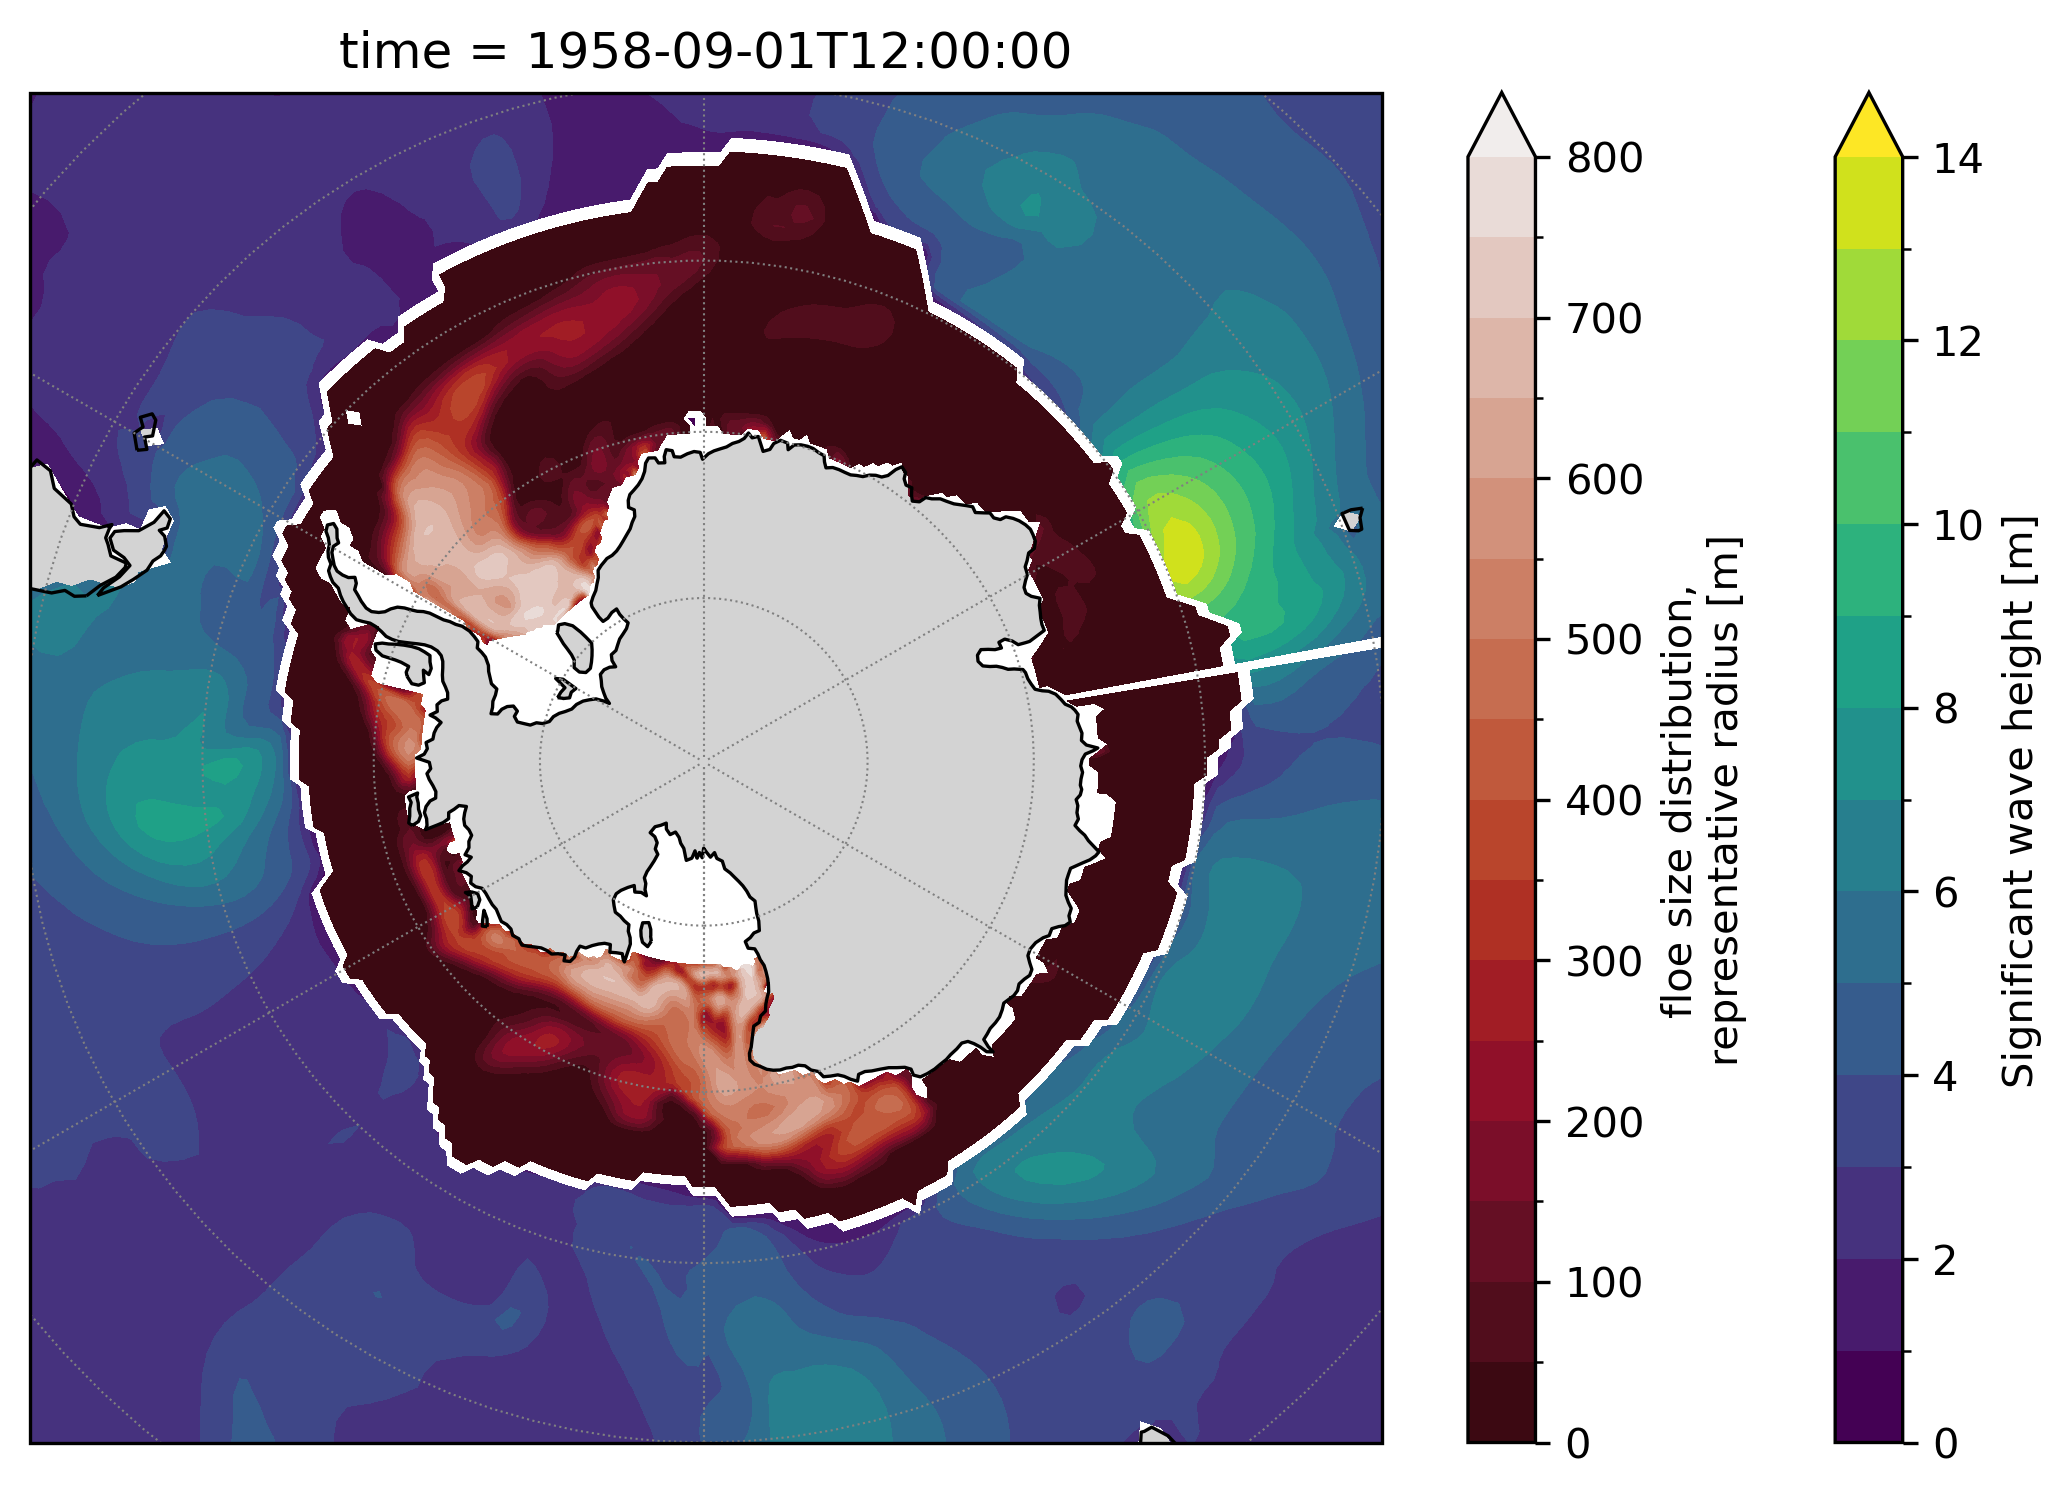

In [84]:
import matplotlib.colors as mcolors

fig, ax = make_fig_antarctica(central_longitude=0)

swh_daily.where(aice_daily < 0.15).plot.contourf(
    ax=ax,
    levels=15,
    vmax=14,
    transform=ccrs.PlateCarree()
)
# axes[0].set_title('WW3')

fsdrad_daily.where(aice_daily > 0.15).plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels = 17,
    # norm=mcolors.LogNorm(vmin=0.1, vmax=1000),
    vmin=0,
    vmax=800,
    cmap=cm.cm.amp_r
)


In [27]:
figpath = "/g/data/ps29/nd0349/access-om3-paper-figs/gif/frames"
os.makedirs(figpath, exist_ok=True)

array([4753, 4754, 4755, 4756, 4757, 4758, 4759, 4760, 4761, 4762, 4763,
       4764, 4765, 4766, 4767, 4768, 4769, 4770, 4771, 4772, 4773, 4774,
       4775, 4776, 4777, 4778, 4779, 4780, 4781, 4782, 4783, 4784, 4785,
       4786, 4787, 4788, 4789, 4790, 4791, 4792, 4793, 4794, 4795, 4796,
       4797, 4798, 4799, 4800, 4801, 4802, 4803, 4804, 4805, 4806, 4807,
       4808, 4809, 4810, 4811, 4812, 4813, 4814, 4815, 4816, 4817, 4818,
       4819, 4820, 4821, 4822, 4823, 4824, 4825, 4826, 4827, 4828, 4829,
       4830, 4831, 4832, 4833, 4834, 4835, 4836, 4837, 4838, 4839, 4840,
       4841, 4842, 4843, 4844, 4845, 4846, 4847, 4848, 4849, 4850, 4851,
       4852, 4853, 4854, 4855, 4856, 4857, 4858, 4859, 4860, 4861, 4862,
       4863, 4864, 4865, 4866, 4867, 4868, 4869, 4870, 4871, 4872, 4873,
       4874, 4875, 4876, 4877, 4878, 4879, 4880, 4881, 4882, 4883, 4884,
       4885, 4886, 4887, 4888, 4889, 4890, 4891, 4892, 4893, 4894, 4895,
       4896, 4897, 4898, 4899, 4900, 4901, 4902, 49

In [55]:
import matplotlib.colors as mcolors

times = swh.time.size
longitudes = np.linspace(0, 360, times, endpoint=False)

for i, (time_idx, clon) in enumerate(zip(np.arange(times-360, times), longitudes)):
    swh_daily = swh.isel(time=time_idx)
    aice_daily = aice.isel(time=time_idx)
    fsdrad_daily = fsdrad.isel(time=time_idx)
    
    fig, ax = make_fig_antarctica(central_longitude=0)
    
    swh_daily.where(aice_daily < 0.15).plot.contourf(
        ax=ax,
        levels=15,
        vmax=14,
        transform=ccrs.PlateCarree()
    )
    # axes[0].set_title('WW3')
    
    fsdrad_daily.where(aice_daily > 0.15).plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels = 17,
        # norm=mcolors.LogNorm(vmin=0.1, vmax=1000),
        vmin=0,
        vmax=800,
        cmap=cm.cm.amp_r
    )


    outfile = os.path.join(figpath, f"MCW_FSD_frame_{i:04d}.png")
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.close(fig)

IndexError: index 4992 is out of bounds for axis 0 with size 4992

In [56]:
import imageio.v2 as imageio

pattern = os.path.join(figpath, "MCW_FSD_frame_*.png")
files = sorted(glob.glob(pattern))

images = [imageio.imread(f) for f in files]

imageio.mimsave(
    os.path.join(figpath, f"MCW_FSD_coupling.gif"),
    images,
    fps=20
)

## Plot SIE and SIA

In [22]:
from xarray import DataTree, map_over_datasets
OBS_TIME_SLICE = slice("1979", "2026")
sh_obs_url = "https://polarwatch.noaa.gov/erddap/griddap/nsidcG02202v4shmday"
nh_obs_url = "https://polarwatch.noaa.gov/erddap/griddap/nsidcG02202v4nhmday"


def open_cdr_dataset(path, area_file):
    ds = xr.open_dataset(path).rename(
        {'cdr_seaice_conc_monthly': 'cdr_conc', 'xgrid':'x','ygrid':'y'}
    )

    # # we also need the area of each gridcell
    areasNd = np.fromfile(area_file, dtype=np.int32).reshape(
        ds.cdr_conc.isel(time=0).shape
    )
    # # Divide by 1000 to get km2 (https://web.archive.org/web/20170817210544/http://nsidc.org/data/polar-stereo/tools_geo_pixel.html#pixel_area)
    areasKmNd_sh = areasNd / 1000
        
    ds["area"] = xr.DataArray(areasKmNd_sh, dims=["y", "x"])
    ds = ds.set_coords("area")

    ds["cdr_conc"] = ds.cdr_conc.where(ds.cdr_conc<=1)  # convert error codes to Nan

    return ds

!wget --ftp-user=anonymous -nc ftp://sidads.colorado.edu/DATASETS/seaice/polar-stereo/tools/pss25area_v3.dat ftp://sidads.colorado.edu/DATASETS/seaice/polar-stereo/tools/psn25area_v3.dat

sh_cdr_xr = open_cdr_dataset(sh_obs_url, "pss25area_v3.dat")

nh_cdr_xr = open_cdr_dataset(
    nh_obs_url,
    'psn25area_v3.dat'
)

cdr_dt = DataTree.from_dict(
    {
        "cdr_sh": sh_cdr_xr,
        'cdr_nh':nh_cdr_xr
    }
)

File ‘pss25area_v3.dat’ already there; not retrieving.
File ‘psn25area_v3.dat’ already there; not retrieving.


In [23]:
def sea_ice_area(sic, area, range=[0.15, 1]):
    return (sic * area).where((sic >= range[0]) * (sic <= range[1])).cf.sum(["x", "y"])
    
def sea_ice_area_model(sic, area, range=[0.15, 1]):
    return (sic * area).where((sic >= range[0]) * (sic <= range[1])).sum(["ni", "nj"])

def sea_ice_extent(sic, area, range=[0.15, 1]):
    return (area).where((sic >= range[0]) * (sic <= range[1])).cf.sum(["x", "y"])

def sea_ice_extent_model(sic, area, range=[0.15, 1]):
    return (area).where((sic >= range[0]) * (sic <= range[1])).sum(["ni", "nj"])

In [24]:
def sea_ice_area_obs(ds):

    # root dataset in datatree is not used
    if ds is None or 'time' not in ds:
        return ds
    
    sic = ds.cdr_conc
    result = sea_ice_area(sic, sic.area).to_dataset(name="cdr_area")

    # Theres a couple of data gaps which should be nan
    result.loc[{"time": "1988-01-01"}] = np.nan
    result.loc[{"time": "1987-12"}] = np.nan

    return result.sel(time=OBS_TIME_SLICE)
obs_area_dt = cdr_dt.map_over_datasets(sea_ice_area_obs)

In [25]:
def sea_ice_extent_obs(ds):

    # root dataset in datatree is not used
    if ds is None or 'time' not in ds:
        return ds
    
    sic = ds.cdr_conc
    result = sea_ice_extent(sic, sic.area).to_dataset(name="cdr_area")

    # Theres a couple of data gaps which should be nan
    result.loc[{"time": "1988-01-01"}] = np.nan
    result.loc[{"time": "1987-12"}] = np.nan

    return result.sel(time=OBS_TIME_SLICE)

In [26]:
obs_area_dt = sea_ice_area_obs(cdr_dt)
obs_si_area_sh = (cdr_dt['cdr_sh']['cdr_conc'] * cdr_dt['cdr_sh']['cdr_conc'].area).sum(dim=["x", "y"]) 
obs_si_area_nh = (cdr_dt['cdr_nh']['cdr_conc'] * cdr_dt['cdr_nh']['cdr_conc'].area).sum(dim=["x", "y"]) 
obs_si_extent_sh = (cdr_dt['cdr_sh']['cdr_conc'].area).where((cdr_dt['cdr_sh']['cdr_conc'] >= 0.15) * (cdr_dt['cdr_sh']['cdr_conc'] <= 1.0)).sum(dim=["x", "y"]) 
obs_si_extent_nh = (cdr_dt['cdr_nh']['cdr_conc'].area).where((cdr_dt['cdr_nh']['cdr_conc'] >= 0.15) * (cdr_dt['cdr_nh']['cdr_conc'] <= 1.0)).sum(dim=["x", "y"]) 

In [36]:
total_extent = obs_si_extent_nh + obs_si_extent_sh
total_extent

<xarray.DataArray 'area' (time: 554)> Size: 4kB
array([29083653.516     , 26290034.175     , 21942127.759     ,
       19852411.737     , 21383975.836     , 24332479.16      ,
       26125167.69      , 27966420.625     , 28164392.195     ,
       27111064.459     , 26189278.973     , 27980914.426     ,
       27999855.041     , 25025500.134     , 20459162.638     ,
       19464149.446     , 20104824.965     , 22029679.226     ,
       24220610.97      , 26158470.78700001, 27300205.05      ,
       27017410.913     , 27481486.914     , 28820694.663     ,
       29271559.088     , 25983728.876     , 20249633.217     ,
       19216413.128     , 19899889.703     , 22191062.411     ,
       24570939.432     , 27185242.914     , 27973844.889     ,
       26987870.256     , 26903036.246     , 28349917.93000001,
       28327455.831     , 26963755.029     , 21634889.787     ,
       19854346.142     , 21537533.564     , 24400408.868     ,
       25926991.463     , 27279311.828     , 27866520.35      ,
       27265543.879     , 26786775.457     , 28498045.594     ,
       28774298.699     , 24743780.399     , 20962474.385     ,
       19776471.259     , 21101087.546     , 23187602.995     ,
       24335895.698     , 26381723.759     , 27734316.659     ,
       26896351.871     , 27186089.905     , 28368413.194     ,
...
       17960925.302     , 19669667.027     , 21237300.62      ,
       23525164.976     , 25180954.555     , 24591541.05      ,
       24054430.853     , 23829393.585     , 24827059.236     ,
       26714695.886     , 24607492.152     , 19146734.719     ,
       17707223.516     , 19948064.799     , 21836899.375     ,
       24129387.349     , 25790741.293     , 25375633.739     ,
       24996537.483     , 24375310.056     , 26353797.67200001,
       26400570.961     , 23662602.741     , 18535453.318     ,
       17136387.51      , 18291460.598     , 21071049.284     ,
       23401613.698     , 24368772.15      , 24740392.194     ,
       24210371.641     , 23891415.356     , 25844294.778     ,
       26160192.708     , 23095007.477     , 17180204.541     ,
       16390074.23      , 18143652.063     , 20201703.681     ,
       22275954.874     , 23305972.675     , 23344635.613     ,
       22373324.455     , 22319762.763     , 24611973.809     ,
       25268815.007     , 22397887.095     , 18822225.004     ,
       17175394.333     , 18679628.146     , 21288726.84      ,
       23148179.209     , 23864844.814     , 23920973.444     ,
       22828597.88      , 22508852.662     , 24612243.636     ,
       24832816.44      , 22616170.51      ])
Coordinates:
  * time     (time) datetime64[ns] 4kB 1978-11-01 1978-12-01 ... 2024-12-01

In [149]:
import pandas as pd

# Convert to million km²
extent_sh_mkm2 = obs_si_extent_sh / 1e6
extent_nh_mkm2 = obs_si_extent_nh / 1e6

# Convert each to dataframe
df_sh = extent_sh_mkm2.to_dataframe(name="extent_sh").reset_index()
df_nh = extent_nh_mkm2.to_dataframe(name="extent_nh").reset_index()



# Merge on time
df = pd.merge(df_sh, df_nh, on="time")

# Convert to dataframe
df["total"] = df["extent_sh"] + df["extent_nh"]

# Add year and month columns
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
# Add decade column
df["decade"] = (df["year"] // 10) * 10

annual_stats = df.groupby("year").agg(
    sh_min=("extent_sh", "min"),
    sh_max=("extent_sh", "max"),
    nh_min=("extent_nh", "min"),
    nh_max=("extent_nh", "max"),
    total_min=("total", "min"),
    total_max=("total", "max")
).reset_index()

# Merge these stats back into the main dataframe
df = pd.merge(df, annual_stats, on="year")

df

,time,extent_sh,extent_nh,total,year,month,decade,sh_min,sh_max,nh_min,nh_max,total_min,total_max
0,1978-11-01,16.672643,12.411010,29.083654,1978,11,1970,11.958027,16.672643,12.411010,14.332007,26.290034,29.083654
1,1978-12-01,11.958027,14.332007,26.290034,1978,12,1970,11.958027,16.672643,12.411010,14.332007,26.290034,29.083654
2,1979-01-01,6.125043,15.817085,21.942128,1979,1,1970,3.284703,18.742546,7.446733,16.818883,19.852412,28.164392
3,1979-02-01,3.284703,16.567709,19.852412,1979,2,1970,3.284703,18.742546,7.446733,16.818883,19.852412,28.164392
4,1979-03-01,4.565093,16.818883,21.383976,1979,3,1970,3.284703,18.742546,7.446733,16.818883,19.852412,28.164392
...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,2024-08-01,17.186347,5.642251,22.828598,2024,8,2020,2.303685,17.957060,4.551793,15.080893,17.175394,24.832816
550,2024-09-01,17.957060,4.551793,22.508853,2024,9,2020,2.303685,17.957060,4.551793,15.080893,17.175394,24.832816
551,2024-10-01,17.263005,7.349238,24.612244,2024,10,2020,2.303685,17.957060,4.551793,15.080893,17.175394,24.832816
552,2024-11-01,15.064205,9.768612,24.832816,2024,11,2020,2.303685,17.957060,4.551793,15.080893,17.175394,24.832816


In [150]:
import numpy as np
import pandas as pd

# Set threshold in million km²
threshold = 5

# Exclude year 1984
df = df[df["year"] != 1984]

# Keep only years where all months are non-NaN AND above threshold
valid_years = df.groupby("year")["total"].apply(lambda x: (x.notna() & (x >= threshold)).all())
valid_years = valid_years[valid_years].index

# Filter dataframe
df_filtered = df[df["year"].isin(valid_years)]

# Replace df with filtered version
df = df_filtered

df

,time,extent_sh,extent_nh,total,year,month,decade,sh_min,sh_max,nh_min,nh_max,total_min,total_max
0,1978-11-01,16.672643,12.411010,29.083654,1978,11,1970,11.958027,16.672643,12.411010,14.332007,26.290034,29.083654
1,1978-12-01,11.958027,14.332007,26.290034,1978,12,1970,11.958027,16.672643,12.411010,14.332007,26.290034,29.083654
2,1979-01-01,6.125043,15.817085,21.942128,1979,1,1970,3.284703,18.742546,7.446733,16.818883,19.852412,28.164392
3,1979-02-01,3.284703,16.567709,19.852412,1979,2,1970,3.284703,18.742546,7.446733,16.818883,19.852412,28.164392
4,1979-03-01,4.565093,16.818883,21.383976,1979,3,1970,3.284703,18.742546,7.446733,16.818883,19.852412,28.164392
...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,2024-08-01,17.186347,5.642251,22.828598,2024,8,2020,2.303685,17.957060,4.551793,15.080893,17.175394,24.832816
550,2024-09-01,17.957060,4.551793,22.508853,2024,9,2020,2.303685,17.957060,4.551793,15.080893,17.175394,24.832816
551,2024-10-01,17.263005,7.349238,24.612244,2024,10,2020,2.303685,17.957060,4.551793,15.080893,17.175394,24.832816
552,2024-11-01,15.064205,9.768612,24.832816,2024,11,2020,2.303685,17.957060,4.551793,15.080893,17.175394,24.832816


In [283]:

def plot_trend_with_corr(ax, df, x_col, y_col, start_year, end_year, color, label=None, ax_text=None, annotate=False):
    df_sub = df[(df[x_col] >= start_year) & (df[x_col] <= end_year)]
    X = df_sub[[x_col]].values
    y = df_sub[y_col].values
    
    # Fit linear regression
    model = LinearRegression().fit(X, y)
    y_fit = model.predict(X)
    ax.plot(df_sub[x_col], y_fit, color=color, linestyle='--', linewidth=2, label=label)
    
    # Compute correlation between original data
    r, p = pearsonr(df_sub[x_col], df_sub[y_col])
    corr_text = f"$r=${r:.2f}"
    if annotate:
    # Annotate near the end of the line
        ax_text = ax_text if ax_text else ax
        ax_text.text(
            df_sub[x_col].values[-1],  # x position at the end of line
            y_fit[-1],                 # y position at end of trend
            corr_text,
            color=color,
            verticalalignment='bottom',
            horizontalalignment='left',
            fontsize=10,
            fontweight='bold',
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="none",
                alpha=0.8
            )
        )

color_total = "black"
color_arctic = np.array([0, 114, 178]) / 255
color_antarctic = np.array([213, 94, 0]) / 255
color_trend_cool = np.array([86, 180, 233]) / 255
color_trend_hot = np.array([204, 121, 167]) / 255

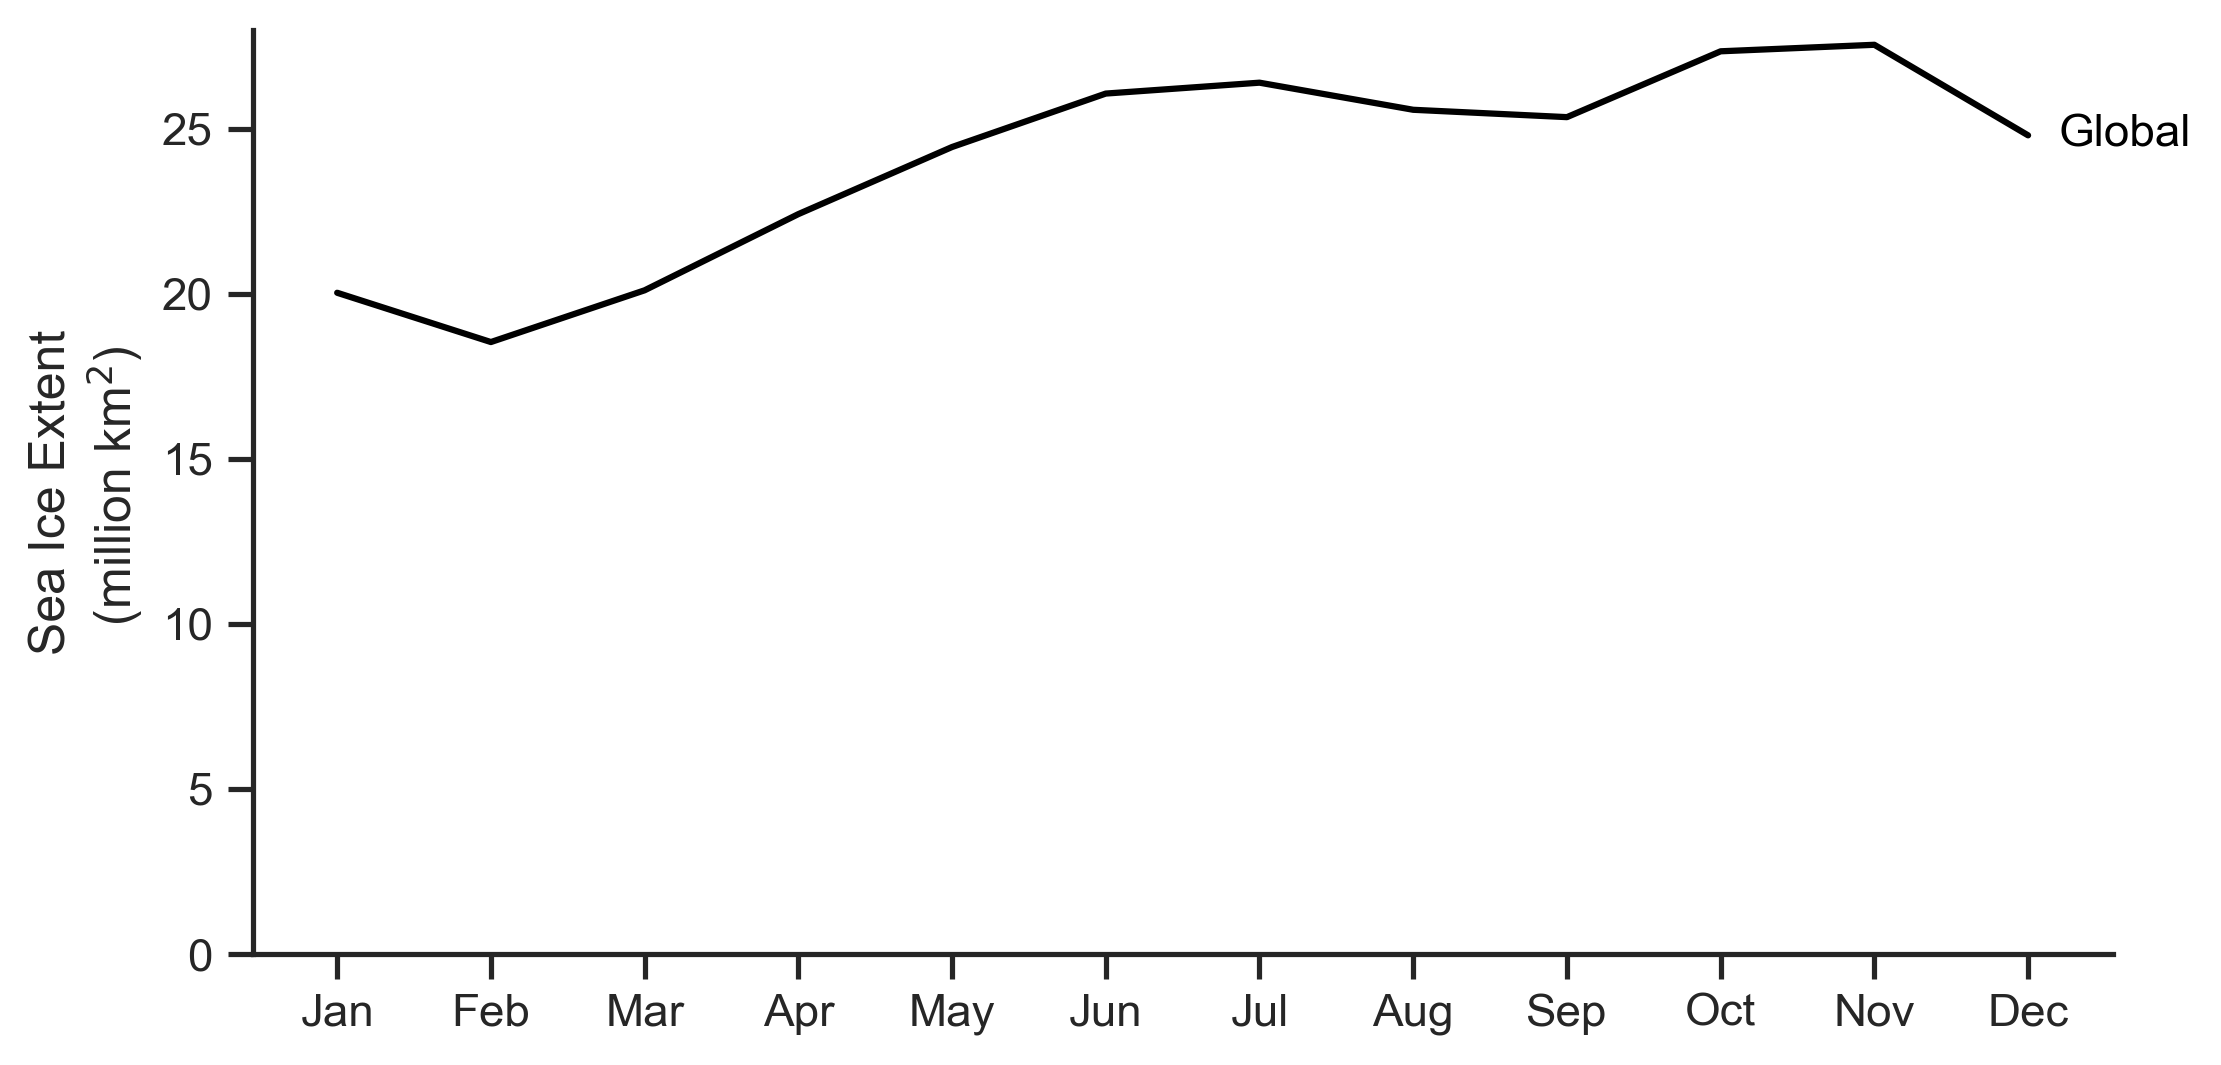

In [339]:
import seaborn as sns

plot = "only"

sns.set_style("ticks")

fig, ax = plt.subplots(figsize=(8,4))


# Total
sns.lineplot(
    data=df,
    x="month",
    y="total",
    errorbar=None,
    color=color_total,
    ax=ax
)

for col, label, color in [
    ("total", "Global", color_total),
]:
    last = df[df["month"] == 12][col].mean()
    ax.text(
        12.2, last, label,
        color=color,
        va="center",
        fontsize=11
    )

if plot == "all":

    sns.lineplot(
        data=df,
        x="month",
        y="extent_nh",
        errorbar=None,
        color=color_arctic,
        ax=ax
    )

    sns.lineplot(
        data=df,
        x="month",
        y="extent_sh",
        errorbar=None,
        color=color_antarctic,
        ax=ax
    )

    # Add labels at end of curves
    for col, label, color in [
        ("extent_nh", "Arctic", color_arctic),
        ("extent_sh", "Antarctic", color_antarctic),
    ]:
        last = df[df["month"] == 12][col].mean()
        ax.text(
            12.2, last, label,
            color=color,
            va="center",
            fontsize=11
        )



ax.set_xlabel("")
ax.set_ylabel("Sea Ice Extent\n (million km$^2$)")
ax.set_xticks(range(1,13))
ax.set_xticklabels(
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"]
)
ax.set_ylim(bottom=0)
sns.despine()
# plt.tight_layout()
plt.savefig(plotfolder+f"annual_SIE_{plot}.png", transparent=True, dpi=900)
plt.show()

In [285]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.set_style("ticks")

# fig, ax = plt.subplots(figsize=(8,4))

# sns.lineplot(
#     data=df,
#     x="month",
#     y="total",
#     hue='decade',
#     errorbar=('ci', 95),
#     ax=ax
# )

# ax.set_xlabel("Month")
# ax.set_ylabel("Sea Ice Extent (million km$^2$)")
# ax.set_xticks(range(1,13))
# ax.set_xticklabels(
#     ["Jan","Feb","Mar","Apr","May","Jun",
#      "Jul","Aug","Sep","Oct","Nov","Dec"]
# )

# sns.despine()
# plt.tight_layout()
# plt.show()

In [286]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.set_style("ticks")

# fig, ax = plt.subplots(figsize=(8,4))

# sns.lineplot(
#     data=df,
#     x="month",
#     y="extent_nh",
#     hue='decade',
#     errorbar=('ci', 95),
#     ax=ax
# )

# sns.lineplot(
#     data=df,
#     x="month",
#     y="extent_sh",
#     hue='decade',
#     errorbar=('ci', 95),
#     legend=False,
#     ax=ax
# )

# ax.set_xlabel("Month")
# ax.set_ylabel("Sea Ice Extent (million km$^2$)")
# ax.set_xticks(range(1,13))
# ax.set_xticklabels(
#     ["Jan","Feb","Mar","Apr","May","Jun",
#      "Jul","Aug","Sep","Oct","Nov","Dec"]
# )

# sns.despine()
# plt.tight_layout()
# plt.show()

In [287]:
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# import numpy as np

# sns.set_style("ticks")

# fig, ax = plt.subplots(figsize=(8,4))

# # Sort years
# years_sorted = np.sort(df['decade'].unique())
# norm = plt.Normalize(years_sorted.min(), years_sorted.max())
# cmap = cm.get_cmap("flare_r")

# # Plot each year as a separate line with corresponding color
# for year in years_sorted:
#     df_year = df[df['year'] == year]
#     ax.plot(df_year['month'], df_year['extent_nh'],
#             color=cmap(norm(year)),
#             label=str(year))  # label can be omitted for cleaner plot

# # Colorbar for the years
# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label("Year")

# ax.set_xlabel("Month")
# ax.set_ylabel("Sea Ice Extent (million km$^2$)")
# ax.set_xticks(range(1,13))
# ax.set_xticklabels(
#     ["Jan","Feb","Mar","Apr","May","Jun",
#      "Jul","Aug","Sep","Oct","Nov","Dec"]
# )

# sns.despine()
# plt.tight_layout()
# plt.show()

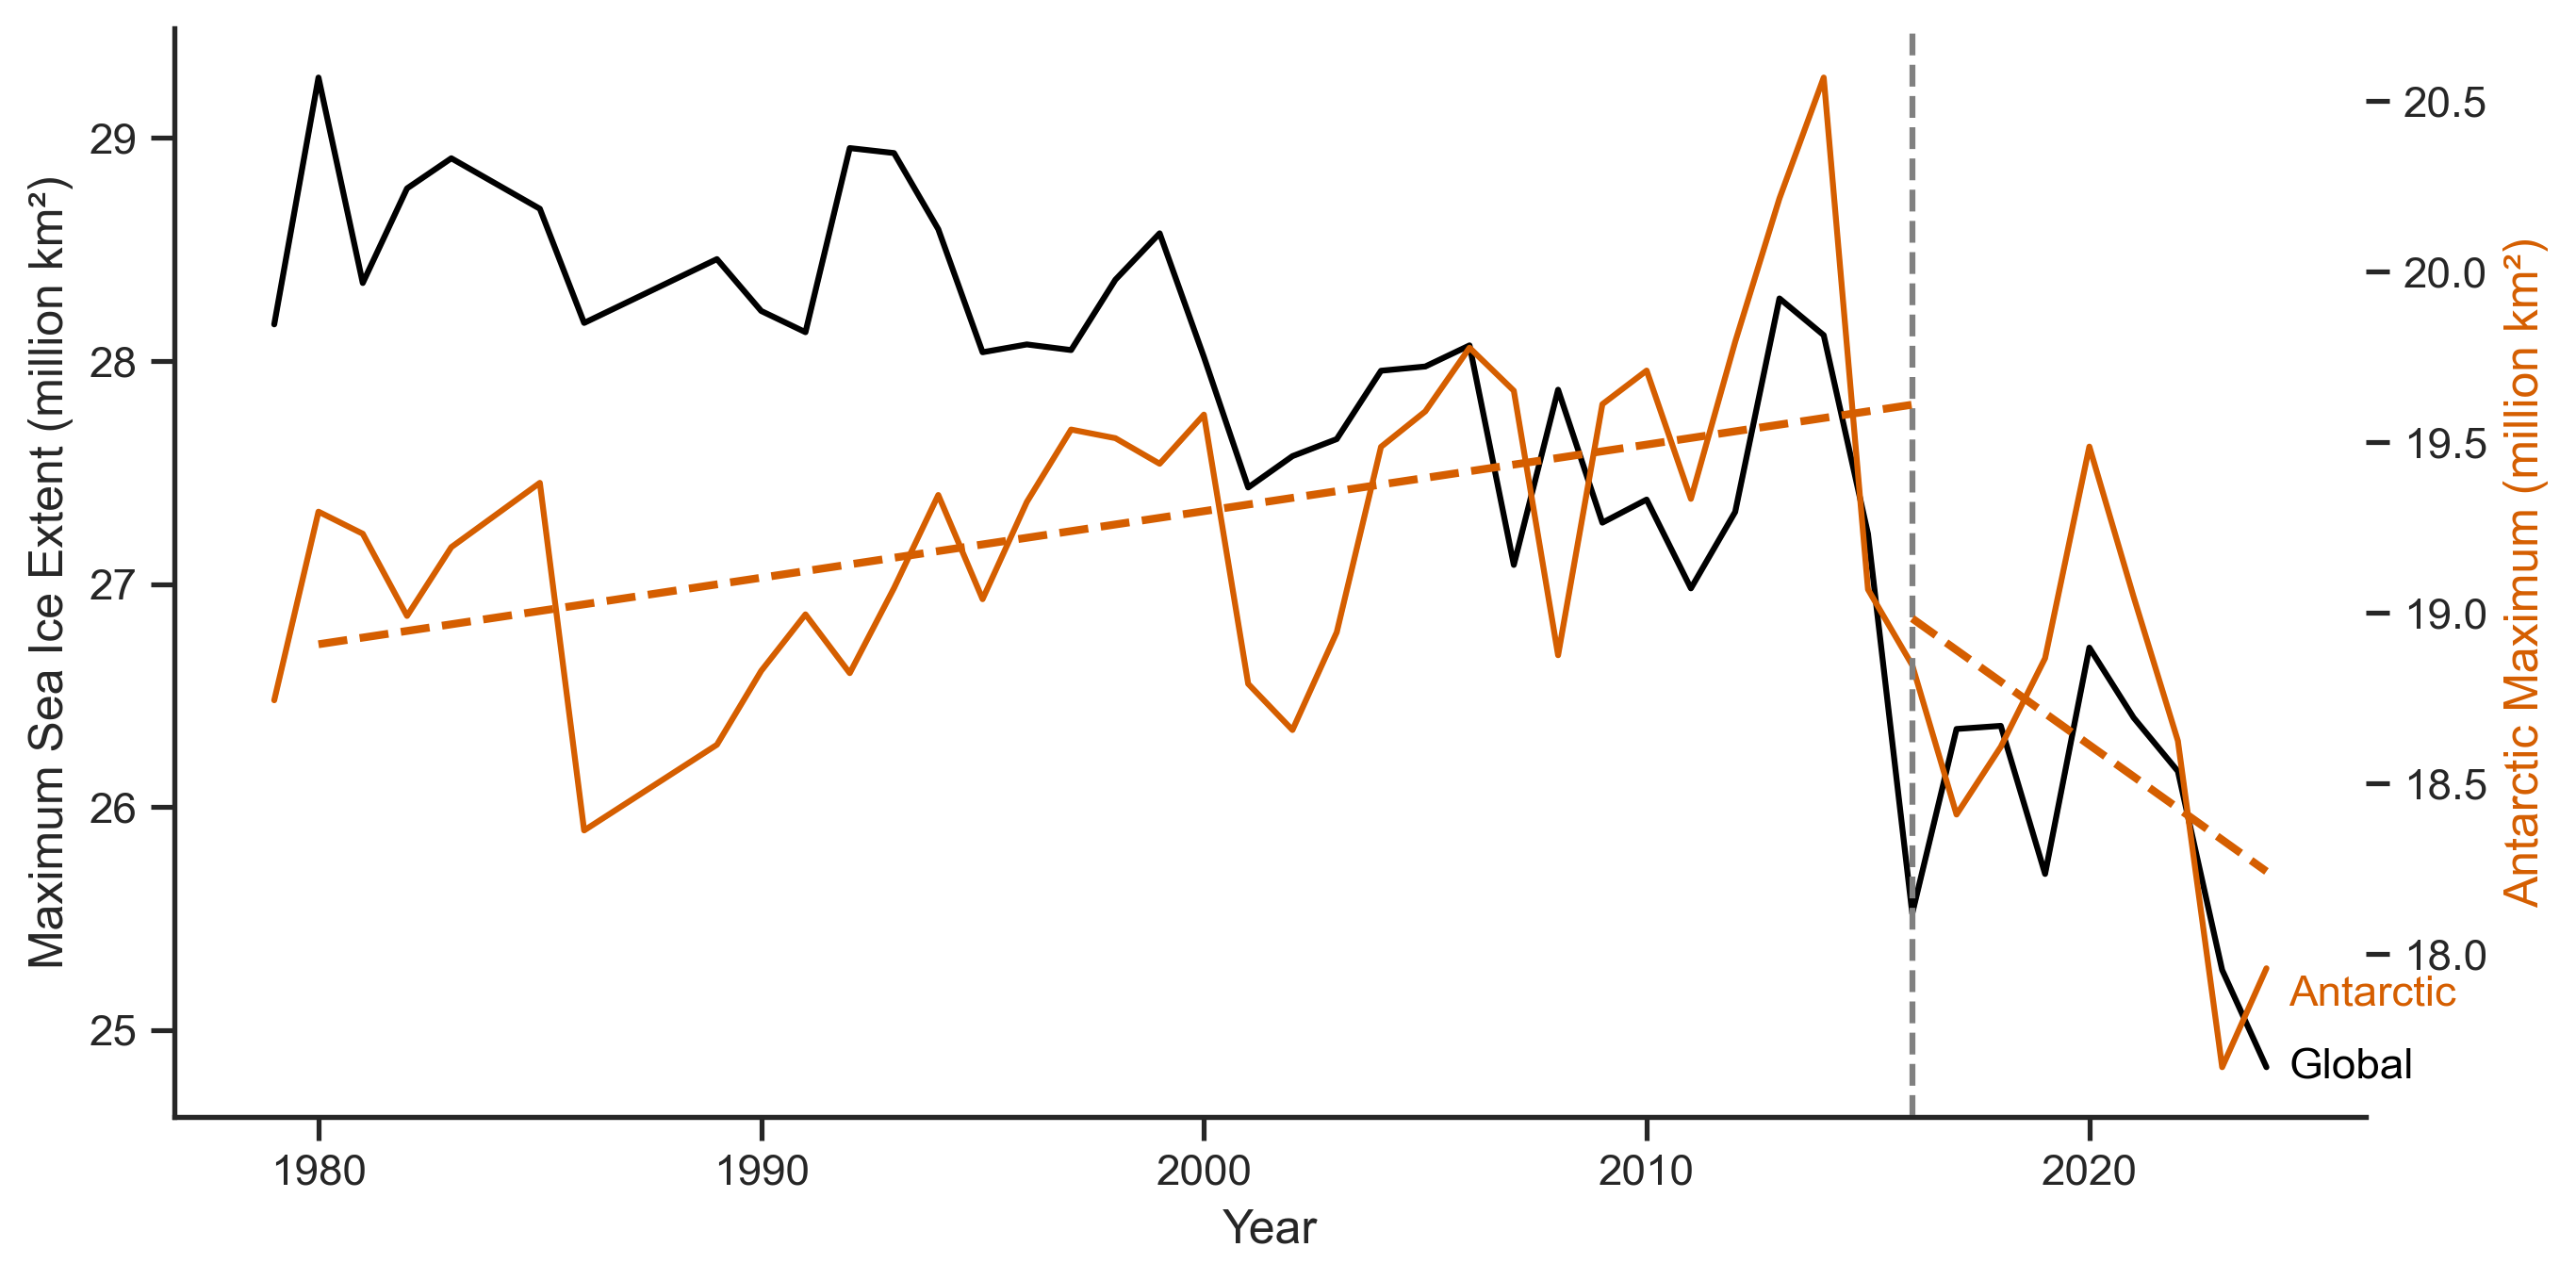

In [343]:
# ==================================================

plot = "antarctic"
trend = True

# ==================================================

fig, ax_left = plt.subplots(figsize=(10,5))
df_plot = df[df['year'] != 1978].copy()
# df_plot = df_plot[df_plot['year'] != 1979].copy()
# Total max on left axis
sns.lineplot(
    data=df_plot,
    x="year",
    y="total_max",
    ax=ax_left,
    color=color_total,
)
ax_left.set_ylabel("Maximum Sea Ice Extent (million km²)")
ax_left.set_xlabel("Year")


last = df_plot[df_plot["year"] == 2024]["total_max"].mean()
ax_left.text(
    2024.5, last, "Global",
    color=color_total,
    va="center",
    fontsize=11
)

if plot == "arctic":
    # NH max on right axis
    ax_right = ax_left.twinx()
    sns.lineplot(
        data=df_plot,
        x="year",
        y="nh_max",
        ax=ax_right,
        color=color_arctic,
        label="NH Max",
        legend=False,
    )
    ax_right.set_ylabel("Northern Hemisphere Maximum (million km²)", color=color_arctic)
    last = df_plot[df_plot["year"] == 2024]["nh_max"].mean()
    ax_right.text(
        2024.5, last, "Arctic",
        color=color_arctic,
        va="center",
        fontsize=11
    )
        
    if trend:
        plot_trend_with_corr(ax_right, df_plot, 'year', 'nh_max', 1980, 2024, color_arctic)
        # plot_trend_with_corr(ax_right, df_plot, 'year', 'nh_max', 2016, 2024, color_trend_cool)
elif plot == "antarctic":
    # NH max on right axis
    ax_right = ax_left.twinx()
    sns.lineplot(
        data=df_plot,
        x="year",
        y="sh_max",
        ax=ax_right,
        color=color_antarctic,
        # label="NH Max",
        legend=False,
    )
    ax_right.set_ylabel("Antarctic Maximum (million km²)", color=color_antarctic)
    last = df_plot[df_plot["year"] == 2024]["sh_max"].mean()-0.075
    ax_right.text(
        2024.5, last, "Antarctic",
        color=color_antarctic,
        va="center",
        fontsize=11
    )
    ax_right.axvline(2016, ls='--', color='gray')
    
    if trend:
        plot_trend_with_corr(ax_right, df_plot, 'year', 'sh_max', 1980, 2016, color_antarctic)
        # plot_trend_with_corr(ax_right, df_plot, 'year', 'sh_max', 2006, 2016, color_trend_cool)
        plot_trend_with_corr(ax_right, df_plot, 'year', 'sh_max', 2016, 2024, color_antarctic)
sns.despine()
if trend:
    plt.savefig(plotfolder+f"SIE_trend_{plot}_trend.png", transparent=True, dpi=900)
else:
    plt.savefig(plotfolder+f"SIE_trend_{plot}.png", transparent=True, dpi=900)
plt.show()

In [319]:
last

22.02488774316667

In [321]:
last

21.484496733833335

In [203]:
# fig, ax = plt.subplots(figsize=(8,4))
# sns.lineplot(
#     data=df,
#     x="year",
#     y="sh_max",
#     # hue='decade',
#     errorbar=('ci', 95),
#     ax=ax
# )